# Final Project 


<br>

---

<br>

# <span style="color:blue"> Analysis of factors contributing to student's Grade in Mathematics </span>


* **Name**:  <span style="color:blue">Koya Kashiwabara</span>
* **Student number**:  <span style="color:blue">0400377184</span>


<br>

### Purpose:


* <span>“The purpose of this Final Project is to identify factors associated with students’ final grade in mathematics and to construct a predictive model for the final grade.</span>
* <span>The **key dependent variable (DV)** is final grade(G3), an integer between 0 and 20. </span>
* <span> The **key independent variables (IVs)** include: </span>

1. Age       ("age" column in the CSV file)
2. Mother's education       ("Medu" column in the CSV file)
3. Father's education       ("Fedu" column in the CSV file)
4. Travel time to the school("traveltime" column in the CSV file)
5. Study time("studytime" column in the CSV file)
6. Failures  ("failures" column in the CSV file)
7. Freetime  ("freetime" column in the CSV file)
8. Going out ("goout" column in the CSV file)
9. Absences  ("absences" column in the CSV file)

(Those descriptions were taken from the dataset's description.)
</span>
* <span style="color:blue">
This dataset contains 395 cases and no missing values. This dataset originally contains 32 variables, three of which are grade point. So, this dataset also has data for 1st and 2nd grade, but I don't use them at this time since it is sure that those factors (at least seemingly) relate to the final grade.</span>

<br>

## Dataset source:

<span style="color:blue">The data come from the [Student Performance](https://archive.ics.uci.edu/dataset/320/student+performance) dataset from the [UCI Machine Learning repository](https://archive.ics.uci.edu/ml/index.php):</span>

<span style="color:blue">Analyses of this dataset have been published previously in [Cortez and Silva(2008)](https://www.semanticscholar.org/paper/61d468d5254730bbecf822c6b60d7d6595d9889c), </span>

</br>

### Reference:
Cortez, Paulo & Silva, Alice. (2008). Using data mining to predict secondary school student performance. EUROSIS. 


___

## Descriptive Statistics



In [1]:
import descriptive as desc

In [2]:
desc.display_central_tendency_table(num=1)
desc.display_dispersion_table(num=2)

<br><br><p><span style="font-size: 1.2em;"><b>Table 1</b>: Central tendency summary statistics.</span></p>

,age,Medu,Fedu,travel,study,failures,freetime,go_out,absences,Grade,pf
mean,16.696,2.749,2.522,1.448,2.035,0.334,3.235,3.109,5.709,10.415,0.671
median,17.000,3.000,2.000,1.000,2.000,0.000,3.000,3.000,4.000,11.000,1.000
mode,16.000,4.000,2.000,1.000,2.000,0.000,3.000,3.000,0.000,10.000,1.000
skew,0.464,-0.317,-0.032,1.601,0.630,2.378,-0.163,0.116,3.658,-0.730,-0.727
kurtosis,-0.016,-1.091,-1.199,2.299,-0.029,4.926,-0.313,-0.776,21.430,0.383,-1.471


<br><br><p><span style="font-size: 1.2em;"><b>Table 2</b>: Dispersion summary statistics.</span></p>

,age,Medu,Fedu,travel,study,failures,freetime,go_out,absences,Grade,pf
st.dev.,1.274,1.093,1.087,0.697,0.838,0.743,0.998,1.112,7.993,4.576,0.47
min,15.000,0.000,0.000,1.000,1.000,0.000,1.000,1.000,0.000,0.000,0.00
max,22.000,4.000,4.000,4.000,4.000,3.000,5.000,5.000,75.000,20.000,1.00
range,7.000,4.000,4.000,3.000,3.000,3.000,4.000,4.000,75.000,20.000,1.00
25th,16.000,2.000,2.000,1.000,1.000,0.000,3.000,2.000,0.000,8.000,0.00
75th,18.000,4.000,3.000,2.000,2.000,0.000,4.000,4.000,8.000,14.000,1.00
IQR,2.000,2.000,1.000,1.000,1.000,0.000,1.000,2.000,8.000,6.000,1.00


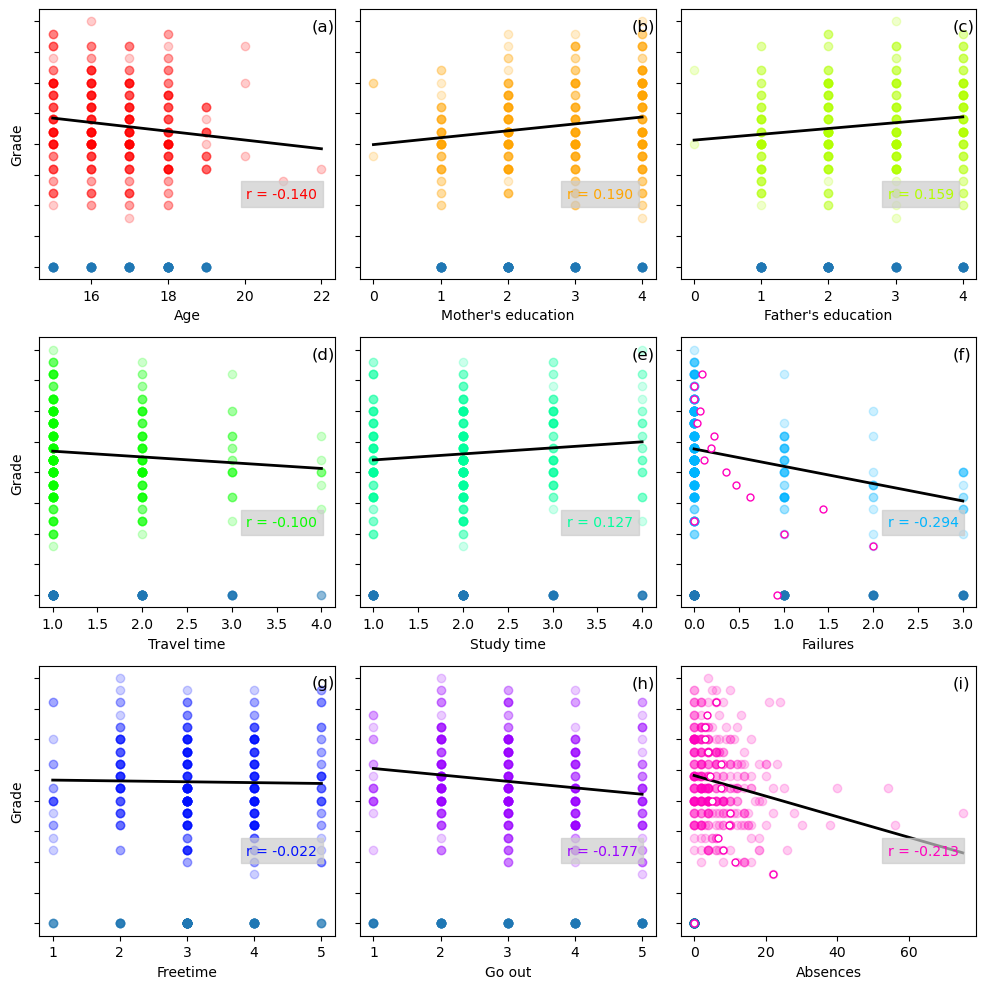

<p><span style="font-size: 1.2em;"><b>Figure 1</b>: Correlations amongst main variables.</span></p><br><br>

In [3]:
desc.plot_descriptive()

___

## **Classical Statistics**



In [4]:
%%capture
%run classical.ipynb

## First analysis
Method : t-test  
Data related: Grade, study time, absences, and failures (processed)  
Objective : To examine which factors make a difference in grade.   
Correspondent analysis in classical.ipynb: Analysis 1 and 3

#### Data process and words explained

I classified each of study time, absences, and failures into two groups. Those groups are described as dummy variables below:
- study time → diligence: calculated by whether its study time exceeds half of the scale: 2.
- failures   → experience of failure: Once and more: 1, no failure: 0
- absences   → participation: calculated by whether the absence exceeds the mean of the population.

The three letters are made of **diligence** + **experience of failure** + **participation**.  
    e.g., n_y_n means a group whose people: are not diligent, have failed, and don't participate much.

<p><span style="font-size: 1.2em;"><b>Figure 2</b>: Significant pairs of groups (study time & absence & failures, p < 0.05)</span></p><br><br>

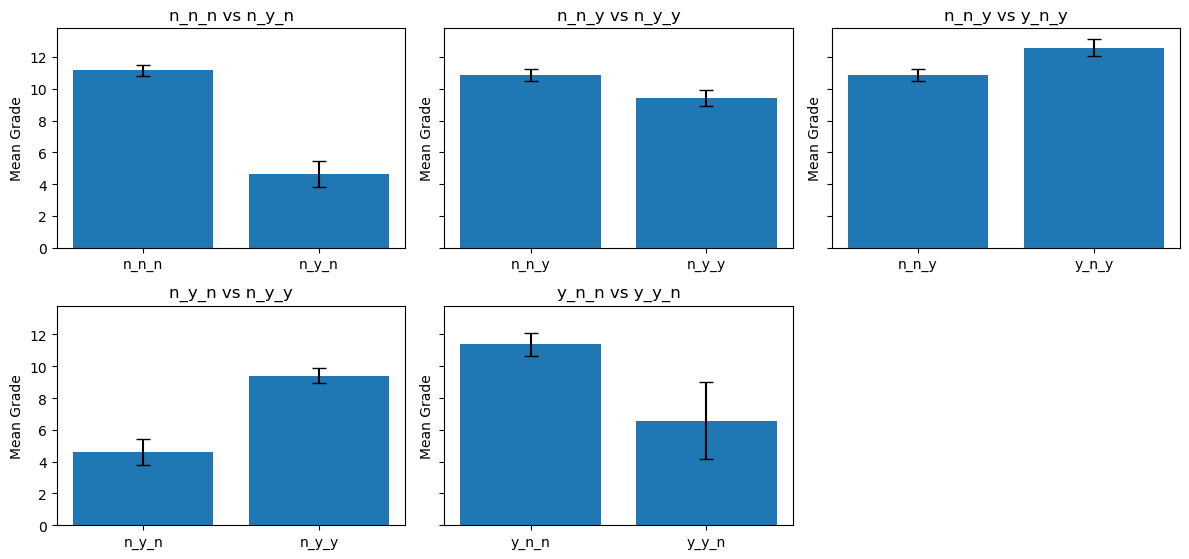

In [5]:
First_analysis(num=2)

### Discussion 1

5 Pairs whose p-value is significant, and one of whose two of the properties(e.g., nyn-nnn) is identical to the other, are shown. 
Again, the "group" made from **diligence** + **experience of failure** + **participation**. (e.g., n_y_n means a group whose people are not diligent, have failed, and don't participate much.)  
  
So, the result, combined with the comparison of the average grades (shown in "classical.ipynb"'s analysis 1), implies that:
- failures and grade, both when students don't study much and student study much but don't participate much, are negatively related.
- Study time and grade, when students have no experience of failure and participate well, are positively related
- The experience of failure is associated with lower grades when students study well and don't participate well.

## Second analysis
Method : t-test  
Data related: Grade, mother's education, father's education, and go out (processed)  
Objective : To examine which factors make a difference in grade.  
Correspondent analysis in classical.ipynb: Analysis 4 and 5

#### Data process and words explained

As first analysis, I classified each of mother's education, father's education, and go out into two groups. Those groups are described as dummy variable below:
- mother's education → mother's higher-than-average education, calculated by whether its mother's education exceeds the mean of the population.
- father's education → father's higher-than-average education, calculated by whether its father's education exceeds the mean of the population.
- goout              → self_control, calculated by whether its time to go out exceeds the mean of the population.

The three letters are made of **mother's higher-than-average education** + **father's higher-than-average education** + **self_control**.  

<p><span style="font-size: 1.2em;"><b>Figure 3</b>: Significant pairs of groups (mother/father's education & going-out, p < 0.05)</span></p><br><br>

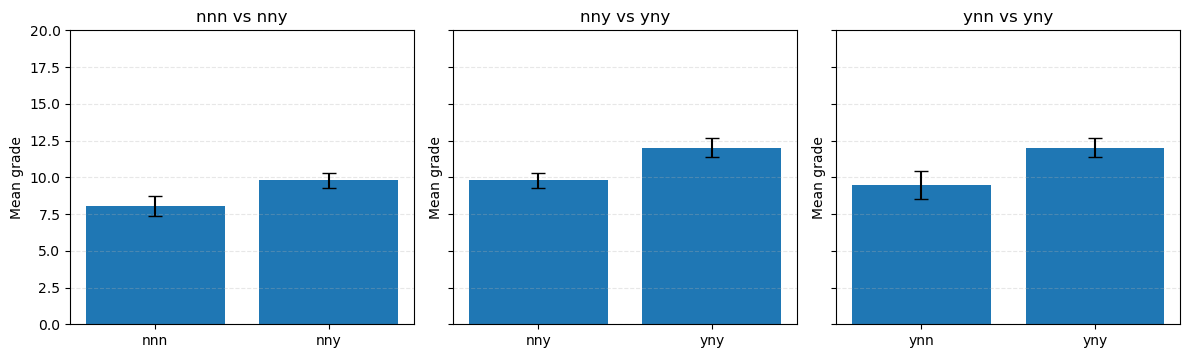

In [6]:
Second_analysis(num=3)

3 Pairs whose p-value is significant, and one of whose two of the properties(e.g., nyn-nnn) is identical to the other, are shown. 

Significant result: **nnn to nny, nny to yny, and ynn to yny**
  
Again, the three letters are made of mother's higher-than-average education + father's higher-than-average education + self_control.
  
So, the result, combined with the comparison of the average grades (shown in "classical.ipynb"'s analysis 4), implies that:
- Less going out and grade when father's education is not so high are positively related.
- mother's education and grade, when father's education is not so high, and the student goes out less, are positively related.

___

## **Machine learning**



In [7]:
%%capture
%run machine.ipynb

---
## Analysis 1
Method      : Regression  
Data related: Grade, with all IVs   
Objective   : Relationship between grade and multiple variables using linear regression.

#### Process before this model is explained

First, I split the dataset into training and test sets (test_size = 0.33). I then fitted a multiple linear regression using all IVs. To simplify the model, I applied backward stepwise elimination by repeatedly removing the predictor with the largest p-value and refitting the model. The final reduced model retained four predictors: failures, mother’s education (Medu), studytime, and age.   
The model performed relatively poorly in both training and test data. Also, the test-set error is relatively large: RMSE ≈ 5 grade points on a 0-20 scale, meaning limited predictive performance. Still, this suggests that the remaining four factors (failures, Mother's education, studytime, age) by stepwise procedure are significantly associated with grade, while a large portion of the variation remains unexplained.

- R2 in training data     0.147757  
- R2 in test data         0.081277  
- MSE in test data       25.658582  


<p><span style="font-size: 1.2em;"><b>Figure 4</b>: Validation: Observed vs Predicted Grade (test data)</span></p><br><br>

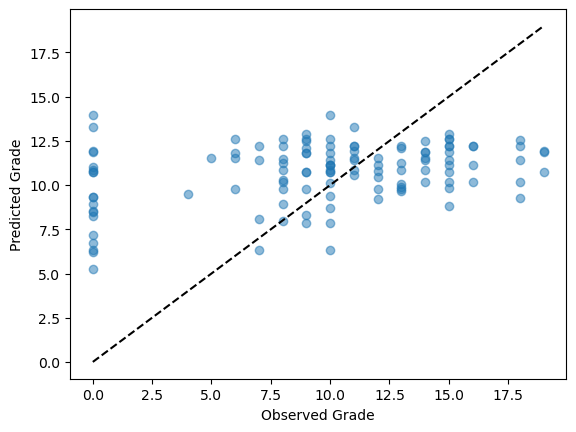

In [8]:
validation_plot(num=4)

From the plot above, any significant linear relation between observed and predicted grades is not visible. Instead, an interesting difference is found, which is that the model predicts grades of almost all students as being in the range of (5, 15), while real grades range from 0 to 20. 

---
## Analysis 2
Method      : Classification by ANN  
Data related: Pass/Fail derived from Grade, with two IVs (absences, Medu)  
Objective   : To build a model to predict pass and fail.

#### Brief note on what was done before this analysis
To study pass/fail outcomes, I converted the grade into a binary label using the same threshold as the prior study: Grade ≥ 10 = pass, otherwise fail. For visualization, I focused on two predictors—mother’s education (Medu) and absences—and plotted the data in this 2D feature space with pass/fail labels. I then trained an ANN classifier and evaluated its performance on both training and test sets. I also tested different values of the regularization parameter (alpha). Because the initial model’s test accuracy did not exceed the pass-rate baseline, I applied standardization and re-trained the classifier, then visualized the decision surface of the standardized model.

<p><span style="font-size: 1.2em;"><b>Figure 5</b>: Pass/ Fail Distribution in 2D: Mother’s Education vs Absences (with test set)</span></p><br><br>

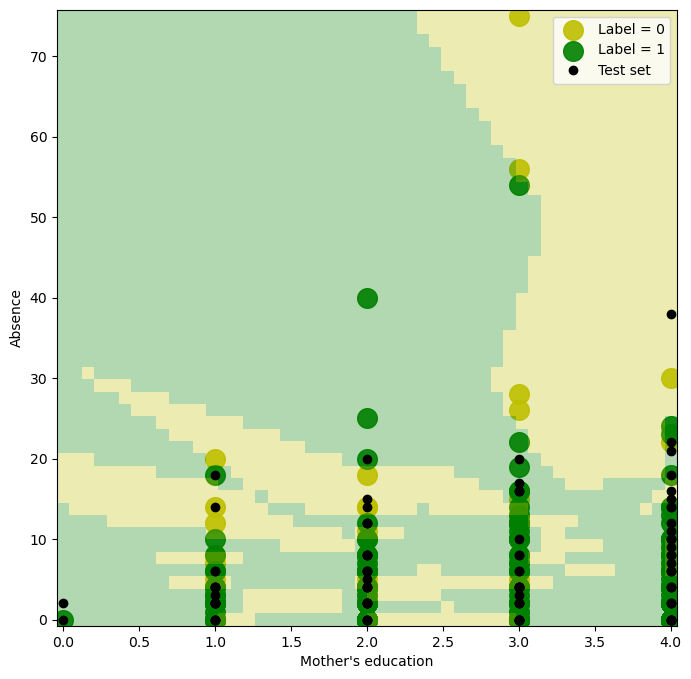

In [9]:
decition_surface(num=5)

In this model, the test accuracy is 0.697, which is only slightly above the pass-rate baseline (0.689). However, because the classes are imbalanced, accuracy alone can be misleading. Therefore, I also report per-class recall: recall(pass)=0.890 and recall(fail)=0.270, giving a balanced accuracy of 0.580. Importantly, the recall for the fail class is not zero, meaning the model identifies some failing students rather than predicting ‘pass’ for everyone. At the same time, fail recall remains relatively low, suggesting that these two predictors (Medu and absences) provide limited information for reliably detecting ‘fail’ in this test set.